# EDA — NWB Intensiteiten (Fileradar AI, Zuid-Holland 2024)

This notebook explores `data/raw/NWB_intensiteiten/` and works out how to load
and join annual traffic intensity estimates into the main pipeline.

**Source:** NDW / Fileradar AI model, annual average 2024, Province Zuid-Holland.
Documented in `20240827 Memo levering intensiteitschattingen.pdf`.

**Key questions:**
1. What columns are available, and what are their types and null rates?
2. What is the CRS — do we need to reproject to RD New (EPSG:28992)?
3. What sentinel values exist? (`-1` = no estimate, `Geen` method)
4. How does `RIJRICHTNG` (H/T) affect the join — do we need to aggregate directions?
5. How many Rotterdam road segments are covered?
6. What is the intensity distribution, and which percentile to use?
7. What is the best join strategy to link intensities to our intersections?

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second_year\Afstuderen\Project\intersections"
SHP_FILE    = os.path.join(PROJECT_DIR, "data", "raw", "NWB_intensiteiten",
                           "intensiteiten_ProvincieZuid-Holland_2024_fileradar.shp")

# Existing pipeline files needed for the join strategy check
WVK_FILE = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst_merged.gpkg")
INT_FILE  = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")

print(f"File size: {os.path.getsize(SHP_FILE) / 1e6:.1f} MB")

File size: 61.2 MB


## 1. Load and inspect structure

The shapefile has 342k rows — one per road segment *per direction* (H = heen, T = terug).
That means dual-carriageway segments appear twice with separate intensity estimates.

In [2]:
# Load the full shapefile — 342k rows fits comfortably in RAM
gdf = gpd.read_file(SHP_FILE)

print(f"Rows          : {len(gdf):,}")
print(f"CRS           : {gdf.crs}")
print(f"Geometry type : {gdf.geom_type.value_counts().to_dict()}")
print()
print("Columns and dtypes:")
for col in gdf.columns:
    if col == "geometry":
        continue
    n_null = gdf[col].isna().sum()
    print(f"  {col:<20} {str(gdf[col].dtype):<12} {n_null:>8,} nulls")

print()
# WVK_ID comes in as float64 due to shapefile limitations; cast to int for joins
print("Note: WVK_ID and JTE_ID_BEG/END are float64 — cast to int before joining.")
print()
gdf.head(3)

Rows          : 342,511
CRS           : GEOGCS["WGS84(DD)",DATUM["WGS84",SPHEROID["WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Geometry type : {'LineString': 342511}

Columns and dtypes:
  WVK_ID               float64             0 nulls
  RIJRICHTNG           str                 0 nulls
  JTE_ID_BEG           float64             0 nulls
  JTE_ID_END           float64             0 nulls
  WEGBEHSRT            str                 0 nulls
  WEGNUMMER            str           333,687 nulls
  HECTO_LTTR           str                 0 nulls
  BST_CODE             str                 0 nulls
  STT_NAAM             str                 0 nulls
  BEGINKM              float64       334,254 nulls
  EINDKM               float64       334,254 nulls
  WEGBEHNAAM           str                16 nulls
  DISTRNAAM            str           339,190 nulls
  WEGNR_AW             str           339,404 nulls
  WEGNR_H

,WVK_ID,RIJRICHTNG,JTE_ID_BEG,JTE_ID_END,WEGBEHSRT,WEGNUMMER,HECTO_LTTR,BST_CODE,STT_NAAM,BEGINKM,...,WEGBEHNAAM,DISTRNAAM,WEGNR_AW,WEGNR_HMP,INTWERKP15,INTWERKP50,INTWERKP85,METHODE,OPMERKING,geometry
0,601049838.0,H,600272194.0,600396933.0,W,NaN,#,RB,Groenedijk,NaN,...,Waterschap De Hollandse Delta,NaN,NaN,NaN,50,100,400,Interpolatie,Zie fileradar.nl voor meer informatie over de ...,"LINESTRING (3.8656 51.811, 3.8657 51.811, 3.86..."
1,601049838.0,T,600396933.0,600272194.0,W,NaN,#,RB,Groenedijk,NaN,...,Waterschap De Hollandse Delta,NaN,NaN,NaN,100,150,200,AI-meting,Zie fileradar.nl voor meer informatie over de ...,"LINESTRING (3.8657 51.811, 3.8657 51.811, 3.86..."
2,600900118.0,H,600013461.0,600187559.0,T,NaN,#,RB,Brouwersdam buitenzijde,NaN,...,Meer instanties,NaN,NaN,NaN,-1,-1,-1,Geen,Zie fileradar.nl voor meer informatie over de ...,"LINESTRING (3.8686 51.785, 3.8686 51.785, 3.86..."


## 2. CRS

The `.prj` file declares WGS84 (EPSG:4326) — confirmed by the coordinate values
(x ≈ 3.87°, y ≈ 51.8°). The pipeline uses RD New (EPSG:28992) throughout.

**For the tabular `WVK_ID` join: no reprojection needed.**
Reprojection is only required if we want to plot this layer on the RD New map.

In [3]:
# Confirm CRS and show how to reproject if needed for plotting
sample = gdf.geometry.iloc[0].coords[0]
print(f"Sample coordinate (x, y) : {sample[0]:.5f}, {sample[1]:.5f}")
print(f"Reported CRS             : {gdf.crs.to_epsg() if gdf.crs else 'None'}")
print()
print("For tabular join: no reprojection needed.")
print("For map plotting: gdf.to_crs(epsg=28992)")

Sample coordinate (x, y) : 3.86565, 51.81135
Reported CRS             : None

For tabular join: no reprojection needed.
For map plotting: gdf.to_crs(epsg=28992)


## 3. Sentinel values and METHODE

Segments where Fileradar could not produce an estimate use `METHODE = 'Geen'`
and have `-1` for all three percentile columns. These must be excluded before
aggregating per intersection.

In [4]:
print("METHODE distribution:")
print(gdf["METHODE"].value_counts(dropna=False).to_string())
print()

# Confirm that -1 values occur only on Geen segments
n_sentinel = (gdf["INTWERKP50"] == -1).sum()
n_geen     = (gdf["METHODE"] == "Geen").sum()
print(f"Rows with INTWERKP50 == -1 : {n_sentinel:,}")
print(f"Rows with METHODE == 'Geen': {n_geen:,}")
print(f"They match: {n_sentinel == n_geen}")
print()

# After excluding Geen, remaining coverage
valid = gdf[gdf["METHODE"] != "Geen"]
print(f"Valid rows (AI-meting + Interpolatie): {len(valid):,}  ({len(valid)/len(gdf)*100:.1f}%)")

METHODE distribution:
METHODE
AI-meting       272101
Interpolatie     49312
Geen             21098

Rows with INTWERKP50 == -1 : 21,098
Rows with METHODE == 'Geen': 21,098
They match: True

Valid rows (AI-meting + Interpolatie): 321,413  (93.8%)


## 4. RIJRICHTNG — direction split

Every segment appears twice: once for direction H (heen) and once for T (terug).
There is no B (both) entry. For a per-intersection intensity metric we want the
**total two-way flow**, so we sum H + T per `WVK_ID` before joining.

In [5]:
print("RIJRICHTNG distribution:")
print(gdf["RIJRICHTNG"].value_counts(dropna=False).to_string())
print()

# Check how many unique WVK_IDs exist vs total rows
n_unique_wvk = gdf["WVK_ID"].nunique()
print(f"Unique WVK_IDs : {n_unique_wvk:,}")
print(f"Total rows     : {len(gdf):,}")
print(f"Ratio          : {len(gdf)/n_unique_wvk:.2f}  (close to 2 = each segment has H and T)")
print()

# Show a pair to illustrate H/T split
example_wvk = gdf["WVK_ID"].iloc[0]
print(f"Example WVK_ID {example_wvk:.0f}:")
print(gdf[gdf["WVK_ID"] == example_wvk][["WVK_ID", "RIJRICHTNG", "INTWERKP15", "INTWERKP50", "INTWERKP85", "METHODE"]].to_string(index=False))

RIJRICHTNG distribution:
RIJRICHTNG
H    196122
T    146389

Unique WVK_IDs : 196,128
Total rows     : 342,511
Ratio          : 1.75  (close to 2 = each segment has H and T)

Example WVK_ID 601049838:
     WVK_ID RIJRICHTNG  INTWERKP15  INTWERKP50  INTWERKP85      METHODE
601049838.0          H          50         100         400 Interpolatie
601049838.0          T         100         150         200    AI-meting


## 5. Intensity distributions

`INTWERKP50` is the recommended point estimate (weekday annual average, vehicles/day).
The P15 and P85 columns give the uncertainty band — 64% of validation points fall
within this band according to the NDW memo.

In [6]:
# Statistics on valid rows only (exclude Geen / -1 sentinel)
valid = gdf[gdf["METHODE"] != "Geen"].copy()

print("Intensity statistics (valid segments, vehicles/day):")
print(valid[["INTWERKP15", "INTWERKP50", "INTWERKP85"]].describe().round(0))
print()

# Percentile spread as a measure of estimate uncertainty
valid["spread"] = valid["INTWERKP85"] - valid["INTWERKP15"]
valid["spread_pct"] = valid["spread"] / valid["INTWERKP50"].replace(0, np.nan) * 100
print(f"Median uncertainty spread (P85-P15) : {valid['spread'].median():.0f} veh/day")
print(f"Median spread as % of P50           : {valid['spread_pct'].median():.0f}%")

Intensity statistics (valid segments, vehicles/day):
       INTWERKP15  INTWERKP50  INTWERKP85
count    321413.0    321413.0    321413.0
mean        911.0      1151.0      1460.0
std        2800.0      3201.0      3646.0
min           0.0         0.0         0.0
25%          50.0       100.0       200.0
50%         100.0       150.0       300.0
75%         500.0       850.0      1250.0
max       80150.0     97650.0    111850.0

Median uncertainty spread (P85-P15) : 200 veh/day
Median spread as % of P50           : 86%


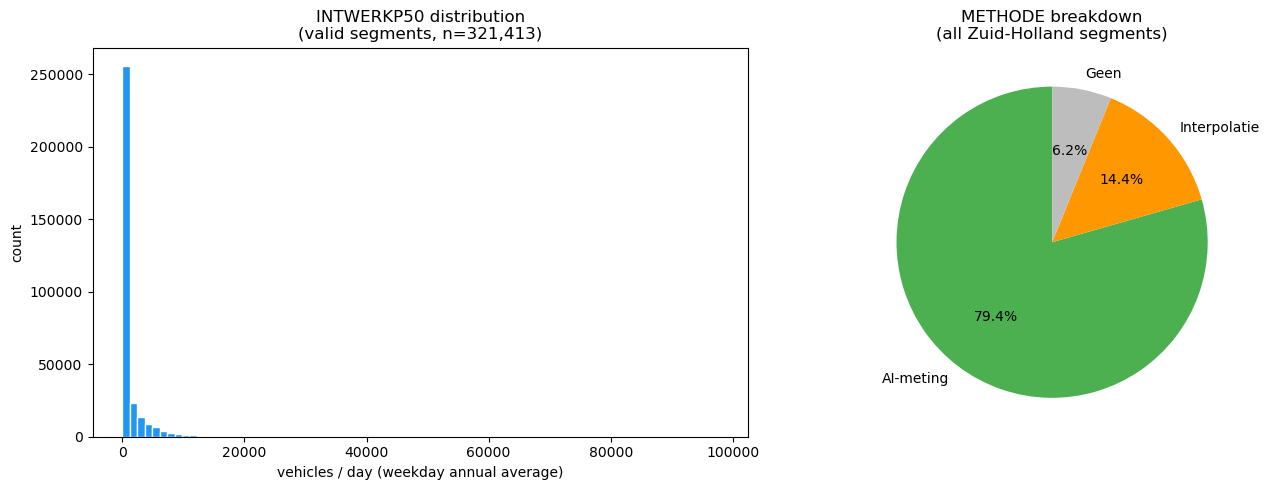

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: INTWERKP50 histogram (log scale for readability) ---
ax = axes[0]
vals = valid["INTWERKP50"]
ax.hist(vals, bins=80, color="#2196F3", edgecolor="white")
ax.set_title(f"INTWERKP50 distribution\n(valid segments, n={len(vals):,})")
ax.set_xlabel("vehicles / day (weekday annual average)")
ax.set_ylabel("count")

# --- Right: METHODE breakdown as pie ---
ax2 = axes[1]
methode_counts = gdf["METHODE"].value_counts()
colors = {"AI-meting": "#4CAF50", "Interpolatie": "#FF9800", "Geen": "#BDBDBD"}
ax2.pie(
    methode_counts.values,
    labels=methode_counts.index,
    colors=[colors.get(m, "#607D8B") for m in methode_counts.index],
    autopct="%1.1f%%",
    startangle=90,
)
ax2.set_title("METHODE breakdown\n(all Zuid-Holland segments)")

plt.tight_layout()
plt.show()

## 6. Rotterdam coverage

Filter to Rotterdam using the WVK_IDs from `wegvakken_rotterdam_bst_merged.gpkg`
(the BST-filtered Rotterdam road segments already used in the pipeline).

In [8]:
# Load Rotterdam wegvakken — attributes only, no geometry needed
wvk = gpd.read_file(WVK_FILE, ignore_geometry=True)
rotterdam_wvk_ids = set(wvk["WVK_ID"].astype(int))

# Cast WVK_ID from float64 to int for matching
gdf_rot = gdf[gdf["WVK_ID"].astype(int).isin(rotterdam_wvk_ids)].copy()

print(f"Zuid-Holland segments total     : {len(gdf):,}")
print(f"Rotterdam BST wegvakken (unique): {len(rotterdam_wvk_ids):,}")
print(f"Matched rows in intensiteiten   : {len(gdf_rot):,}")
print(f"Unique WVK_IDs matched          : {gdf_rot['WVK_ID'].nunique():,}")
print(f"Coverage (WVK_IDs)              : {gdf_rot['WVK_ID'].nunique()/len(rotterdam_wvk_ids)*100:.1f}%")
print()
print("METHODE for Rotterdam segments:")
print(gdf_rot["METHODE"].value_counts(dropna=False).to_string())
print()
valid_rot = gdf_rot[gdf_rot["METHODE"] != "Geen"]
print("INTWERKP50 (valid Rotterdam segments, vehicles/day):")
print(valid_rot["INTWERKP50"].describe().round(0))

Zuid-Holland segments total     : 342,511
Rotterdam BST wegvakken (unique): 24,837
Matched rows in intensiteiten   : 37,306
Unique WVK_IDs matched          : 23,160
Coverage (WVK_IDs)              : 93.2%

METHODE for Rotterdam segments:
METHODE
AI-meting       30691
Interpolatie     4675
Geen             1940

INTWERKP50 (valid Rotterdam segments, vehicles/day):
count    35366.0
mean      1461.0
std       2637.0
min          0.0
25%        150.0
50%        300.0
75%       1400.0
max      30200.0
Name: INTWERKP50, dtype: float64


## 7. Join strategy — from intensity to intersection

The intensiteiten file already contains `JTE_ID_BEG` and `JTE_ID_END` from NWB —
so we can build the junction → segment mapping directly from this file, without
needing to go through `wegvakken_rotterdam_bst_merged.gpkg` separately.

**Steps:**
1. Aggregate H + T rows per `WVK_ID` → total two-way `INTWERKP50`
2. Build long-format junction → WVK_ID table from `JTE_ID_BEG` and `JTE_ID_END`
3. Look up intensity per segment
4. Aggregate per junction: `sum` (total approaching flow) or `max` (busiest leg)
5. Join to intersections on `JTE_ID`

**Why sum?** Intersections experience conflict from all approach legs combined;
total flow is the standard exposure metric in traffic safety.

In [9]:
# --- Step 1: aggregate H+T per WVK_ID for valid segments only ---
# Sum P50 across directions to get two-way daily flow per road segment.
# Segments with METHODE='Geen' (value -1) are excluded before summing.
valid_rot = gdf_rot[gdf_rot["METHODE"] != "Geen"].copy()
valid_rot["WVK_ID_int"] = valid_rot["WVK_ID"].astype(int)

wvk_intensity = (
    valid_rot.groupby("WVK_ID_int")["INTWERKP50"]
    .sum()
    .rename("intensity_twoway")
)
print(f"WVK_IDs with valid intensity: {len(wvk_intensity):,}")

# --- Step 2: build junction → WVK_ID long table from the intensity file itself ---
# Each row has both JTE_ID_BEG and JTE_ID_END; we unpivot to get one row per
# (junction, segment) pair, same approach as in eda_snelheden.
jte_beg = valid_rot[["JTE_ID_BEG", "WVK_ID_int"]].rename(columns={"JTE_ID_BEG": "JTE_ID"})
jte_end = valid_rot[["JTE_ID_END", "WVK_ID_int"]].rename(columns={"JTE_ID_END": "JTE_ID"})
jte_wvk = pd.concat([jte_beg, jte_end]).drop_duplicates()
jte_wvk["JTE_ID"] = jte_wvk["JTE_ID"].astype(int)
print(f"Junction–segment pairs: {len(jte_wvk):,}")

# --- Step 3: look up two-way intensity per connected segment ---
jte_wvk["intensity"] = jte_wvk["WVK_ID_int"].map(wvk_intensity)

# --- Step 4: aggregate per junction ---
intensity_per_jte = (
    jte_wvk.dropna(subset=["intensity"])
    .groupby("JTE_ID")["intensity"]
    .agg(intensity_sum="sum", intensity_max="max", intensity_mean="mean")
    .reset_index()
)

# --- Step 5: merge onto intersections and check match rate ---
intersections = gpd.read_file(INT_FILE)
intersections["JTE_ID_int"] = intersections["JTE_ID"].astype(int)
merged = intersections.merge(
    intensity_per_jte.rename(columns={"JTE_ID": "JTE_ID_int"}),
    on="JTE_ID_int",
    how="left"
)

n_matched = merged["intensity_sum"].notna().sum()
print(f"\nIntersections total          : {len(merged):,}")
print(f"With intensity data          : {n_matched:,}  ({n_matched/len(merged)*100:.1f}%)")
print(f"Without intensity data       : {len(merged) - n_matched:,}")
print()
print("intensity_sum distribution (vehicles/day, all approach legs combined):")
print(merged["intensity_sum"].describe().round(0))

WVK_IDs with valid intensity: 22,162
Junction–segment pairs: 44,324

Intersections total          : 4,715
With intensity data          : 4,565  (96.8%)
Without intensity data       : 150

intensity_sum distribution (vehicles/day, all approach legs combined):
count     4565.0
mean      6271.0
std       8269.0
min          0.0
25%        950.0
50%       2450.0
75%       8200.0
max      66650.0
Name: intensity_sum, dtype: float64


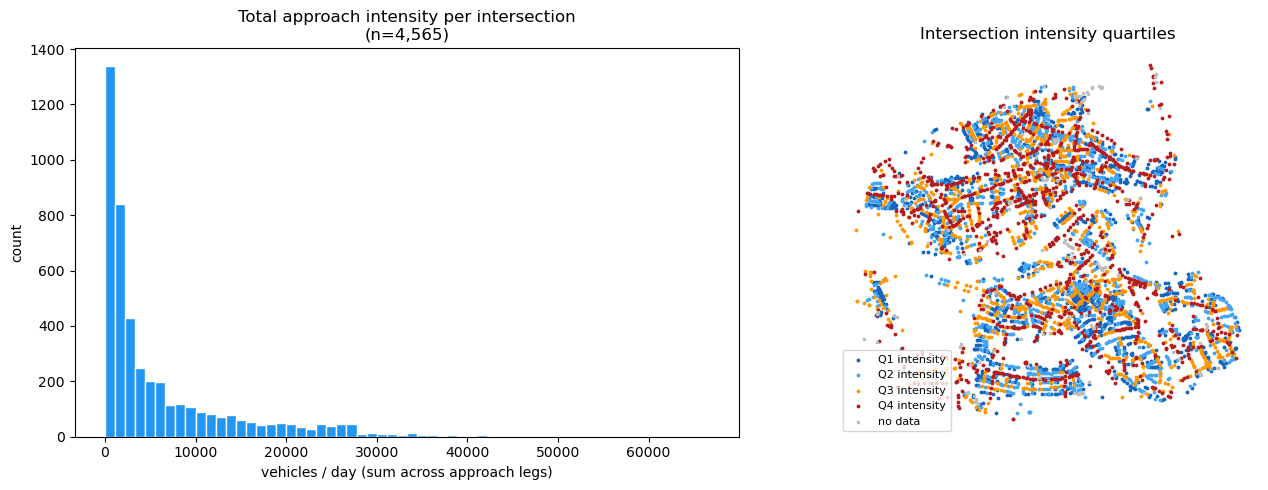

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: per-intersection intensity_sum histogram ---
ax = axes[0]
vals = merged["intensity_sum"].dropna()
ax.hist(vals, bins=60, color="#2196F3", edgecolor="white")
ax.set_title(f"Total approach intensity per intersection\n(n={len(vals):,})")
ax.set_xlabel("vehicles / day (sum across approach legs)")
ax.set_ylabel("count")

# --- Right: map coloured by intensity quartile ---
ax2 = axes[1]
no_data = merged[merged["intensity_sum"].isna()]
has_data = merged[merged["intensity_sum"].notna()].copy()
has_data["quartile"] = pd.qcut(has_data["intensity_sum"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

quartile_colors = {"Q1": "#1565C0", "Q2": "#42A5F5", "Q3": "#FF9800", "Q4": "#B71C1C"}
for q, grp in has_data.groupby("quartile"):
    grp.plot(ax=ax2, color=quartile_colors[q], markersize=3, label=f"{q} intensity")
if len(no_data) > 0:
    no_data.plot(ax=ax2, color="#BDBDBD", markersize=3, marker="x", label="no data")

ax2.set_title("Intersection intensity quartiles")
ax2.set_axis_off()
ax2.legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Summary — what to implement in the pipeline

**Dataset verdict:** ready to use.
- Annual average 2024, weekday, per road segment per direction.
- Direct `WVK_ID` join key — same strategy as the snelheden join.
- `-1` sentinel for `METHODE='Geen'` (6.2% of rows) — exclude before aggregating.
- CRS is WGS84; tabular join needs no reprojection.

**Recommended pipeline integration (notebook 04 or 03):**

```python
# 1. Load and filter to Rotterdam
gdf = gpd.read_file(SHP_FILE, ignore_geometry=True)  # attributes only — no geometry needed
gdf = gdf[gdf["WVK_ID"].astype(int).isin(rotterdam_wvk_ids)]
gdf = gdf[gdf["METHODE"] != "Geen"]                  # drop sentinel rows

# 2. Two-way total per WVK_ID (sum H + T)
wvk_intensity = gdf.groupby(gdf["WVK_ID"].astype(int))["INTWERKP50"].sum()

# 3. Junction → WVK_ID → intensity (both BEG and END junctions)
# ... same pattern as in eda_snelheden cell 4 ...

# 4. Aggregate per junction — use sum for total exposure
intensity_per_jte = jte_wvk.groupby("JTE_ID")["intensity"].agg(intensity_sum="sum")

# 5. Save cache to avoid reloading the full Zuid-Holland shapefile
intensity_per_jte.to_csv("data/processed/intensiteiten_rotterdam.csv")
```

**Column to add to output CSV:** `intensity_sum`
(INTWERKP50 summed over all approach legs, two-way, weekday annual average vehicles/day)

## 9. Drempelwaarden voor laag / midden / hoog

We willen `intensity_sum` indelen in drie buckets. Hieronder verkennen we percentiel-gebaseerde grenswaarden op de Rotterdam-snede (`merged`, n=4 565 kruispunten met data).

Twee kandidaat-strategieën:
- **Gelijke derde-percentielen (P33 / P67)**: elke bucket bevat ~33% van de kruispunten.
- **Domein-aangedreven grenzen**: bijv. P25 / P75, of vaste rijkswegen-drempels (bijv. < 2 000 / 2 000–10 000 / > 10 000 vrtg/dag).

Percentielen van intensity_sum (vrtg/dag, som over alle aanrijrichtingen):
  Percentiel      Waarde
--------------------------
  P5                 450
  P10                600
  P20                850
  P25                950
  P33              1,300
  P40              1,700
  P50              2,450
  P60              3,900
  P67              5,600
  P75              8,200
  P80             10,700
  P90             18,480
  P95             24,990

Naam                            Grens laag  Grens hoog   %laag  %midden   %hoog
--------------------------------------------------------------------------------
Gelijke derden (P33/P67)             1,300       5,600   32.3%    34.9%   32.8%
Kwartielen (P25/P75)                   950       8,200   23.5%    51.6%   24.9%
P20/P80                                850      10,700   19.5%    60.5%   19.9%
Vast 2000/10000                      2,000      10,000   44.7%    34.2%   21.1%
Vast 1500/6000                       1,500       6,000   36.0%    

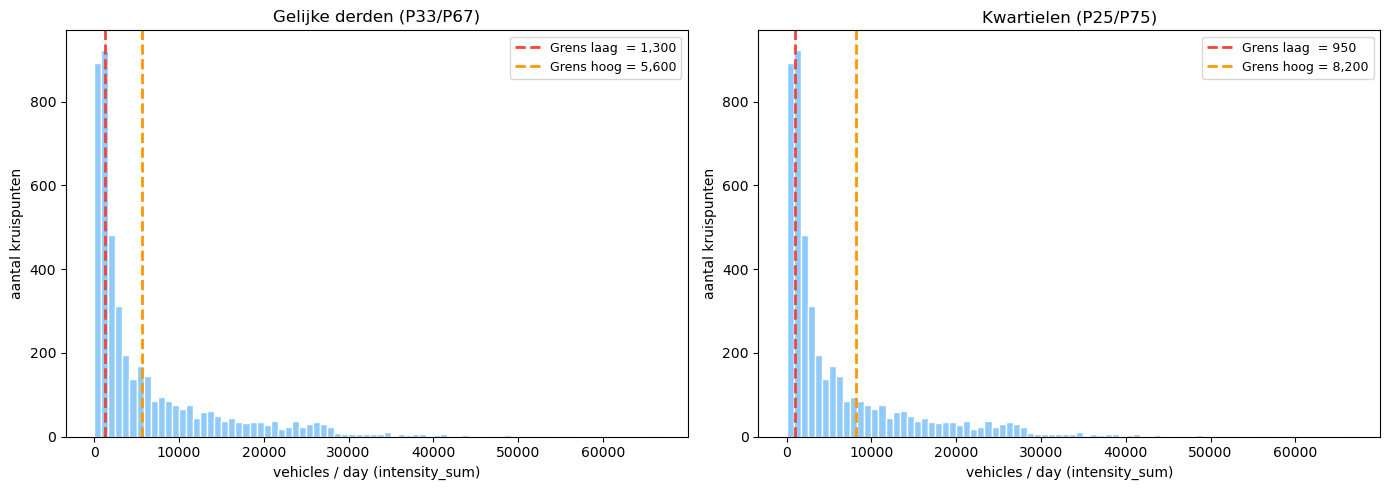

In [11]:
vals = merged["intensity_sum"].dropna()

# --- Percentiel-tabel: breed spectrum om het landschap te begrijpen ---
pcts = [5, 10, 20, 25, 33, 40, 50, 60, 67, 75, 80, 90, 95]
pct_vals = {p: vals.quantile(p / 100) for p in pcts}

print("Percentielen van intensity_sum (vrtg/dag, som over alle aanrijrichtingen):")
print(f"{'Percentiel':>12}  {'Waarde':>10}")
print("-" * 26)
for p, v in pct_vals.items():
    print(f"  P{p:<9}  {v:>10,.0f}")

print()

# --- Kandidaat-drempelsets ---
# Elke set definieert twee grenzen (low_max, high_min).
# Alles < low_max → laag; low_max..high_min → midden; > high_min → hoog.
candidates = {
    "Gelijke derden (P33/P67)": (pct_vals[33], pct_vals[67]),
    "Kwartielen (P25/P75)":     (pct_vals[25], pct_vals[75]),
    "P20/P80":                   (pct_vals[20], pct_vals[80]),
    "Vast 2000/10000":           (2000, 10000),
    "Vast 1500/6000":            (1500, 6000),
}

print(f"{'Naam':<30}  {'Grens laag':>10}  {'Grens hoog':>10}  {'%laag':>6}  {'%midden':>7}  {'%hoog':>6}")
print("-" * 80)
for naam, (lo, hi) in candidates.items():
    n_low  = (vals < lo).sum()
    n_mid  = ((vals >= lo) & (vals <= hi)).sum()
    n_high = (vals > hi).sum()
    n_tot  = len(vals)
    print(f"{naam:<30}  {lo:>10,.0f}  {hi:>10,.0f}  "
          f"{n_low/n_tot*100:>5.1f}%  {n_mid/n_tot*100:>6.1f}%  {n_high/n_tot*100:>5.1f}%")

print()

# --- Visualisatie: histogram met de twee meest interessante drempelsets ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (naam, (lo, hi)) in zip(axes, list(candidates.items())[:2]):
    ax.hist(vals, bins=80, color="#90CAF9", edgecolor="white")
    ax.axvline(lo, color="#F44336", linewidth=2, linestyle="--", label=f"Grens laag  = {lo:,.0f}")
    ax.axvline(hi, color="#FF9800", linewidth=2, linestyle="--", label=f"Grens hoog = {hi:,.0f}")
    ax.set_title(naam)
    ax.set_xlabel("vehicles / day (intensity_sum)")
    ax.set_ylabel("aantal kruispunten")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()